In [1]:
from uxsim import *
from IPython.display import display, Image

/home/david/anaconda3/envs/firstenv/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
W_0 = WorldLocalChoice(
    d=0,
    name="simple_demo",    # Scenario name. Can be blank. Used as the folder name for saving results.
    deltan=5,   # Simulation aggregation unit Δn. Defines how many vehicles are grouped together (i.e., platoon size) for computation. Computation cost is generally inversely proportional to deltan^2.
    tmax=5000,  # Total simulation time (s)
    print_mode=1, save_mode=1, show_mode=1,    # Various options. print_mode determines whether to print information. Usually set to 1, but recommended 0 when running multiple simulations automatically. save_mode determines if visualization results are saved. show_mode determines if visualization results are displayed. It's good to set show_mode=1 on Jupyter Notebook, otherwise recommended 0.
    random_seed=380,    # Set the random seed. Specify if you want repeatable experiments. If not, set to None. 
    duo_update_weight=0.5,
    duo_update_time=100
)

In [3]:
W_0.addNode("nod0", 0.5, -1)
W_0.addNode("nod1", 0.5, 0)
W_0.addNode("nod2", 0, 1)
W_0.addNode("nod3", 1, 1)
W_0.addNode("nod4", 0, 2)
W_0.addNode("nod5", -1, 1)
W_0.addNode("nod6", 1, 1.5)
W_0.addNode("nod7", 1, 2)
W_0.addNode("nod8", 1, 2.5)
W_0.addNode("nod9", 1, 3)
W_0.addNode("nod10", 0.5, 3.5)

W_0.addLink('link0', 'nod0', 'nod1', length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link1", "nod1", "nod2", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) # Create a link. Parameters: link name, start node, end node, length, free_flow_speed, number of lanes, merge_priority during merging
W_0.addLink("link2", "nod1", "nod3", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link3", "nod2", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link4", "nod5", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link5", "nod4", "nod10", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link6", "nod3", "nod6", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link7", "nod6", "nod7", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link8", "nod7", "nod8", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link9", "nod8", "nod9", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_0.addLink("link10", "nod9", "nod10", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) 

<Link link10>

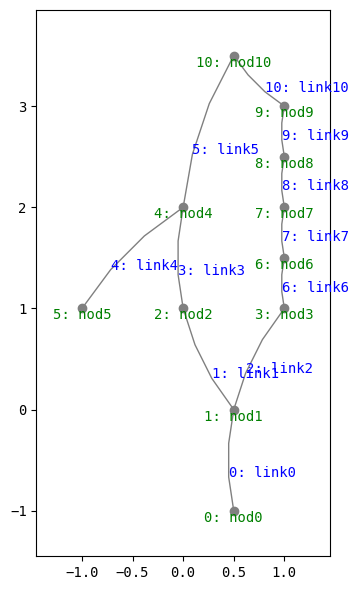

In [4]:
W_0.show_network()

In [5]:
W_0.adddemand("nod5", "nod10", 0, 4500, 50) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
W_0.adddemand("nod0", "nod10", 0, 4500, 50) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod3", "nod6", 0, 300, 30) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod4", "nod6", 500, 800, 20) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
#W.adddemand("nod2", "nod6", 0, 500, 5) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate

In [6]:
W_0.exec_simulation()

simulation setting:
 scenario name: simple_demo
 simulation duration:	 5000 s
 number of vehicles:	 450000 veh
 total road length:	 11000 m
 time discret. width:	 5 s
 platoon size:		 5 veh
 number of timesteps:	 1000
 number of platoons:	 90000
 number of links:	 11
 number of nodes:	 11
 setup time:		 3.30 s
simulating...
      time| # of vehicles| ave speed| computation time
       0 s|        0 vehs|   0.0 m/s|     0.00 s
     600 s|      320 vehs|  16.0 m/s|    16.36 s
    1200 s|      320 vehs|  16.7 m/s|    29.08 s
    1800 s|      340 vehs|  15.0 m/s|    42.73 s
    2400 s|      350 vehs|  14.9 m/s|    55.68 s
    3000 s|      335 vehs|  14.3 m/s|    68.93 s
    3600 s|      375 vehs|  14.6 m/s|    81.98 s
    4200 s|      385 vehs|  11.4 m/s|    95.40 s
    4800 s|      460 vehs|  10.1 m/s|   110.33 s
    5000 s|      495 vehs|   9.7 m/s|   115.27 s
 simulation finished


1

In [7]:
W_0.analyzer.print_simple_stats()

results:
 average speed:	 24.6 m/s
 number of completed trips:	 6035 / 450000
 average travel time of trips:	 2526.4 s
 average delay of trips:	 2395.7 s
 delay ratio:			 0.948
 total distance traveled:	 26952375.0 m


 generating animation...


  0%|          | 0/42 [00:00<?, ?it/s]

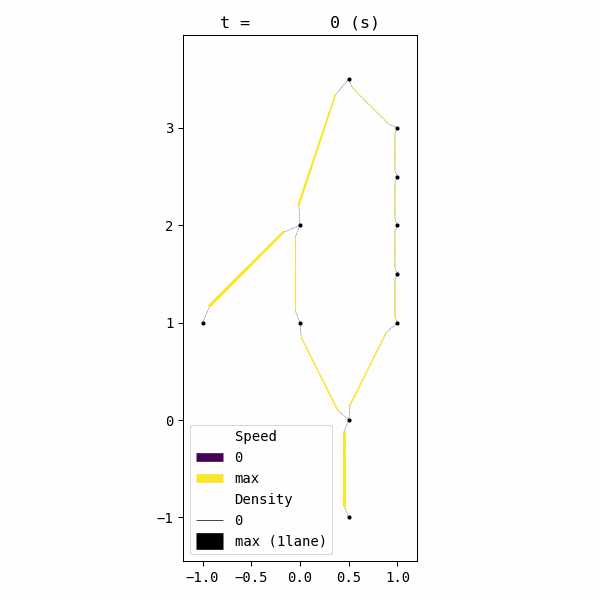

In [8]:
W_0.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0)

with open("outsimple_demo/anim_network1.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

In [ ]:
W_3 = WorldLocalChoice(
    d=4,
    name="simple_demo",    # Scenario name. Can be blank. Used as the folder name for saving results.
    deltan=5,   # Simulation aggregation unit Δn. Defines how many vehicles are grouped together (i.e., platoon size) for computation. Computation cost is generally inversely proportional to deltan^2.
    tmax=5000,  # Total simulation time (s)
    print_mode=1, save_mode=1, show_mode=1,    # Various options. print_mode determines whether to print information. Usually set to 1, but recommended 0 when running multiple simulations automatically. save_mode determines if visualization results are saved. show_mode determines if visualization results are displayed. It's good to set show_mode=1 on Jupyter Notebook, otherwise recommended 0.
    random_seed=380,    # Set the random seed. Specify if you want repeatable experiments. If not, set to None. 
    duo_update_weight=0.5,
    duo_update_time=100
)

W_3.addNode("nod0", 0.5, -1)
W_3.addNode("nod1", 0.5, 0)
W_3.addNode("nod2", 0, 1)
W_3.addNode("nod3", 1, 1)
W_3.addNode("nod4", 0, 2)
W_3.addNode("nod5", -1, 1)
W_3.addNode("nod6", 1, 1.5)
W_3.addNode("nod7", 1, 2)
W_3.addNode("nod8", 1, 2.5)
W_3.addNode("nod9", 1, 3)
W_3.addNode("nod10", 0.5, 3.5)

W_3.addLink('link0', 'nod0', 'nod1', length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link1", "nod1", "nod2", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) # Create a link. Parameters: link name, start node, end node, length, free_flow_speed, number of lanes, merge_priority during merging
W_3.addLink("link2", "nod1", "nod3", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link3", "nod2", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link4", "nod5", "nod4", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link5", "nod4", "nod10", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link6", "nod3", "nod6", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link7", "nod6", "nod7", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link8", "nod7", "nod8", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link9", "nod8", "nod9", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5)
W_3.addLink("link10", "nod9", "nod10", length=1000, free_flow_speed=25, number_of_lanes=1, merge_priority=1.5) 

W_3.adddemand("nod5", "nod10", 0, 4500, 50) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate
W_3.adddemand("nod0", "nod10", 0, 4500, 50) # Create OD traffic demand. Parameters: origin node, destination node, start time, end time, demand flow rate3

W_3.exec_simulation()

W_3.analyzer.print_simple_stats() 

simulation setting:
 scenario name: simple_demo
 simulation duration:	 5000 s
 number of vehicles:	 450000 veh
 total road length:	 11000 m
 time discret. width:	 5 s
 platoon size:		 5 veh
 number of timesteps:	 1000
 number of platoons:	 90000
 number of links:	 11
 number of nodes:	 11
 setup time:		 9.22 s
simulating...
      time| # of vehicles| ave speed| computation time
       0 s|        0 vehs|   0.0 m/s|     0.00 s
     600 s|      320 vehs|  16.0 m/s|    13.17 s
    1200 s|      320 vehs|  16.7 m/s|    26.33 s
    1800 s|      340 vehs|  15.0 m/s|    39.48 s
    2400 s|      350 vehs|  14.9 m/s|    52.86 s
    3000 s|      335 vehs|  14.3 m/s|    66.57 s


 generating animation...


  0%|          | 0/42 [00:00<?, ?it/s]

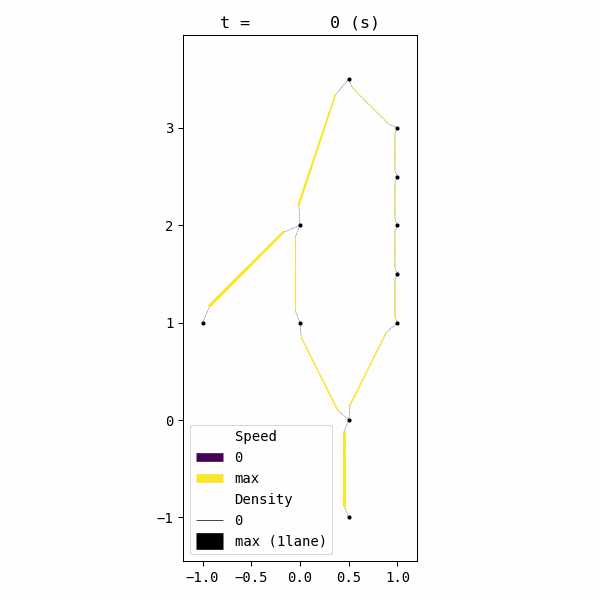

In [3]:
W_3.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0)

with open("outsimple_demo/anim_network1.gif", "rb") as f:
    display(Image(data=f.read(), format='png'))

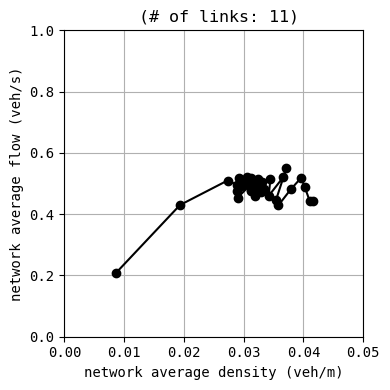

In [5]:
W_3.analyzer.macroscopic_fundamental_diagram(kappa=0.05, qmax=1)

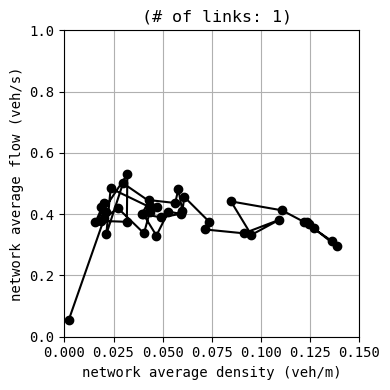

In [42]:
W.analyzer.macroscopic_fundamental_diagram(links=['link3'], kappa=0.15, qmax=1)